# Phase 3: AI Regime Detection (Hidden Markov Model)
## Agricultural Risk Dashboard

Fit a 2-state Gaussian HMM on the Phase 2 idiosyncratic residuals to uncover Calm vs. Crisis regimes per commodity. The HMM treats the regime $S_t \in \{0, 1\}$ as hidden and the residual as the observed emission. Its learned outputs are:

- state-conditional mean + variance,
- a 2x2 transition matrix $P$,
- the posterior probability $P(S_t = \text{Crisis} \mid \text{residuals})$ for every day,
- the most-likely-state sequence (used for regime labels on the chart, posterior > 0.5 flickers, Viterbi is smooth).

Crisis periods with posterior probability > 90% and duration >= 5 trading days are exported for the manual event study.

### 3.1 Load Phase 2 Outputs

Load the residuals and volatility produced by the Phase 2 leave-one-out regression. The HMM is fit on residuals, IVol is kept only for visualization.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

COMMODITIES = ['Corn', 'Soybean', 'Wheat', 'Cotton', 'Coffee', 'Oats', 'Sugar', 'Soybean_Oil', 'Lumber']

residuals = pd.read_csv('data/processed/residuals.csv', parse_dates=['Date'])
volatility = pd.read_csv('data/processed/volatility.csv', parse_dates=['Date'])

print(f'Residuals: {residuals.shape}')
print(f'Volatility: {volatility.shape}')
print(f'Date range: {residuals["Date"].iloc[0].date()} to {residuals["Date"].iloc[-1].date()}')

Residuals: (9601, 10)
Volatility: (9601, 19)
Date range: 1986-01-03 to 2026-03-02


### 3.2 Fit 2-State Gaussian HMM (with multi-restart EM)

The Baum-Welch algorithm is non-convex, so a single EM run with a fixed seed can settle in a local optimum. Fit the model `N_RESTARTS` times with different seeds and keep the run with the highest log-likelihood. After convergence we identify the crisis state as the one with the larger emission variance.

Stored per commodity: Viterbi state sequence, crisis posterior probability, transition matrix, and the state-conditional means/variances.

In [2]:
N_RESTARTS = 8
hmm_results = {}

for target in COMMODITIES:
    mask = residuals[target].notna()
    X = residuals.loc[mask, target].values.reshape(-1, 1)
    dates = residuals.loc[mask, 'Date'].values

    best_ll = -np.inf
    best_model = None
    for seed in range(N_RESTARTS):
        m = GaussianHMM(n_components=2, covariance_type='diag', n_iter=200, tol=1e-4, random_state=seed)
        try:
            m.fit(X)
            ll = m.score(X)
            if ll > best_ll:
                best_ll = ll
                best_model = m
        except Exception:
            continue

    model = best_model
    viterbi = model.predict(X)
    posteriors = model.predict_proba(X)
    state_vars = model.covars_.reshape(2, -1)[:, 0]
    crisis_state = int(np.argmax(state_vars))
    normal_state = 1 - crisis_state

    hmm_results[target] = {
        'dates': dates,
        'viterbi': viterbi,
        'crisis_prob': posteriors[:, crisis_state],
        'crisis_state': crisis_state,
        'means': model.means_.flatten(),
        'variances': state_vars,
        'transmat': model.transmat_,
        'log_lik': best_ll,
    }

    print(f'{target:<12s} | ll={best_ll:11.1f} | '
          f'Normal (mu={model.means_[normal_state][0]:+.5f}, var={state_vars[normal_state]:.6f}) | '
          f'Crisis (mu={model.means_[crisis_state][0]:+.5f}, var={state_vars[crisis_state]:.6f}) | '
          f'var ratio={state_vars[crisis_state]/state_vars[normal_state]:5.2f}x')

    del model, best_model, viterbi, posteriors

Model is not converging.  Current: 27875.406621424536 is not greater than 27875.40844497588. Delta is -0.001823551345296437
Model is not converging.  Current: 27875.40480347006 is not greater than 27875.407150912604. Delta is -0.0023474425433960278
Model is not converging.  Current: 27875.405414926918 is not greater than 27875.405477958786. Delta is -6.30318681942299e-05
Model is not converging.  Current: 27875.40594711056 is not greater than 27875.407904322405. Delta is -0.001957211843546247
Model is not converging.  Current: 27875.403229560186 is not greater than 27875.40345642019. Delta is -0.00022686000374960713
Model is not converging.  Current: 27875.40720296558 is not greater than 27875.40787210383. Delta is -0.0006691382513963617


Corn         | ll=    27875.4 | Normal (mu=+0.00027, var=0.000100) | Crisis (mu=-0.00068, var=0.000454) | var ratio= 4.55x


Model is not converging.  Current: 29630.371204836545 is not greater than 29630.372119082847. Delta is -0.0009142463022726588
Model is not converging.  Current: 29630.375187689446 is not greater than 29630.37749867099. Delta is -0.0023109815447242
Model is not converging.  Current: 29630.371968996882 is not greater than 29630.374222385555. Delta is -0.0022533886731253006
Model is not converging.  Current: 29630.28947348064 is not greater than 29630.2895504925. Delta is -7.701186041231267e-05
Model is not converging.  Current: 29630.48356750156 is not greater than 29630.485558574546. Delta is -0.0019910729861294385
Model is not converging.  Current: 29630.37277234555 is not greater than 29630.373346876157. Delta is -0.000574530607991619
Model is not converging.  Current: 29630.372825394246 is not greater than 29630.37561185478. Delta is -0.0027864605326612946
Model is not converging.  Current: 29630.368097937226 is not greater than 29630.370506228286. Delta is -0.0024082910604192875


Soybean      | ll=    29630.5 | Normal (mu=+0.00031, var=0.000080) | Crisis (mu=-0.00159, var=0.000442) | var ratio= 5.54x


Model is not converging.  Current: 25622.307636061963 is not greater than 25622.307885714963. Delta is -0.0002496529996278696
Model is not converging.  Current: 25622.307939046343 is not greater than 25622.308337409493. Delta is -0.0003983631504524965
Model is not converging.  Current: 25622.301823251037 is not greater than 25622.3020247515. Delta is -0.00020150046475464478
Model is not converging.  Current: 25622.29949947015 is not greater than 25622.299634691248. Delta is -0.00013522109657060355
Model is not converging.  Current: 25622.306076288085 is not greater than 25622.306626923357. Delta is -0.0005506352717929985
Model is not converging.  Current: 25622.298241057826 is not greater than 25622.298244271067. Delta is -3.2132411433849484e-06
Model is not converging.  Current: 25622.30680188528 is not greater than 25622.306980068144. Delta is -0.0001781828650564421
Model is not converging.  Current: 25873.409759548413 is not greater than 25873.415199599513. Delta is -0.0054400510998

...

Coffee       | ll=    23814.9 | Normal (mu=+0.00021, var=0.000198) | Crisis (mu=-0.00093, var=0.001724) | var ratio= 8.71x


Model is not converging.  Current: 25361.071349317568 is not greater than 25361.07872412037. Delta is -0.007374802800768521
Model is not converging.  Current: 25361.074307058738 is not greater than 25361.078974330718. Delta is -0.004667271979997167
Model is not converging.  Current: 25360.600819740594 is not greater than 25360.604698079103. Delta is -0.003878338509821333
Model is not converging.  Current: 25361.06652786891 is not greater than 25361.075124393945. Delta is -0.00859652503640973
Model is not converging.  Current: 25360.903108137096 is not greater than 25360.90764528784. Delta is -0.0045371507439995185
Model is not converging.  Current: 25361.063172065482 is not greater than 25361.076322127738. Delta is -0.013150062255590456


Oats         | ll=    25361.1 | Normal (mu=+0.00017, var=0.000142) | Crisis (mu=-0.00055, var=0.002282) | var ratio=16.05x
Sugar        | ll=    24378.1 | Normal (mu=+0.00016, var=0.000226) | Crisis (mu=-0.00052, var=0.001248) | var ratio= 5.52x
Soybean_Oil  | ll=    28366.0 | Normal (mu=-0.00011, var=0.000102) | Crisis (mu=+0.00050, var=0.000310) | var ratio= 3.02x


Model is not converging.  Current: 24790.820320237395 is not greater than 24790.83490659186. Delta is -0.014586354463972384
Model is not converging.  Current: 24792.335163691416 is not greater than 24792.35012499217. Delta is -0.014961300752474926
Model is not converging.  Current: 24792.314759113757 is not greater than 24792.32333716818. Delta is -0.00857805442501558
Model is not converging.  Current: 24792.38247813999 is not greater than 24792.40679179314. Delta is -0.02431365314987488
Model is not converging.  Current: 24792.31579586955 is not greater than 24792.327174390775. Delta is -0.011378521227015881


Lumber       | ll=    24792.4 | Normal (mu=-0.00037, var=0.000187) | Crisis (mu=+0.00053, var=0.000644) | var ratio= 3.45x


### 3.3 Transition Matrices

$P(\text{Crisis} \mid \text{Crisis})$ near 1 means crises are persistent. The implied expected crisis duration is $1 / (1 - P(\text{Crisis} \mid \text{Crisis}))$ trading days.

In [3]:
for target in COMMODITIES:
    r = hmm_results[target]
    cs = r['crisis_state']
    ns = 1 - cs
    tm = r['transmat']
    exp_calm = 1.0 / max(1e-9, 1 - tm[ns, ns])
    exp_crisis = 1.0 / max(1e-9, 1 - tm[cs, cs])
    print(f'\n{target}')
    print(f'  P(Normal -> Normal) = {tm[ns, ns]:.4f}    P(Normal -> Crisis) = {tm[ns, cs]:.4f}')
    print(f'  P(Crisis -> Normal) = {tm[cs, ns]:.4f}    P(Crisis -> Crisis) = {tm[cs, cs]:.4f}')
    print(f'  Expected duration (days):  Calm ~ {exp_calm:.0f},  Crisis ~ {exp_crisis:.0f}')


Corn
  P(Normal -> Normal) = 0.9747    P(Normal -> Crisis) = 0.0253
  P(Crisis -> Normal) = 0.0715    P(Crisis -> Crisis) = 0.9285
  Expected duration (days):  Calm ~ 40,  Crisis ~ 14

Soybean
  P(Normal -> Normal) = 0.9789    P(Normal -> Crisis) = 0.0211
  P(Crisis -> Normal) = 0.1177    P(Crisis -> Crisis) = 0.8823
  Expected duration (days):  Calm ~ 47,  Crisis ~ 8

Wheat
  P(Normal -> Normal) = 0.9799    P(Normal -> Crisis) = 0.0201
  P(Crisis -> Normal) = 0.0812    P(Crisis -> Crisis) = 0.9188
  Expected duration (days):  Calm ~ 50,  Crisis ~ 12

Cotton
  P(Normal -> Normal) = 0.9803    P(Normal -> Crisis) = 0.0197
  P(Crisis -> Normal) = 0.4156    P(Crisis -> Crisis) = 0.5844
  Expected duration (days):  Calm ~ 51,  Crisis ~ 2

Coffee
  P(Normal -> Normal) = 0.9315    P(Normal -> Crisis) = 0.0685
  P(Crisis -> Normal) = 0.2592    P(Crisis -> Crisis) = 0.7408
  Expected duration (days):  Calm ~ 15,  Crisis ~ 4

Oats
  P(Normal -> Normal) = 0.9155    P(Normal -> Crisis) = 0.0845
 

### 3.4 Visualize Regime Detection

Plot each commodity's annualized IVol

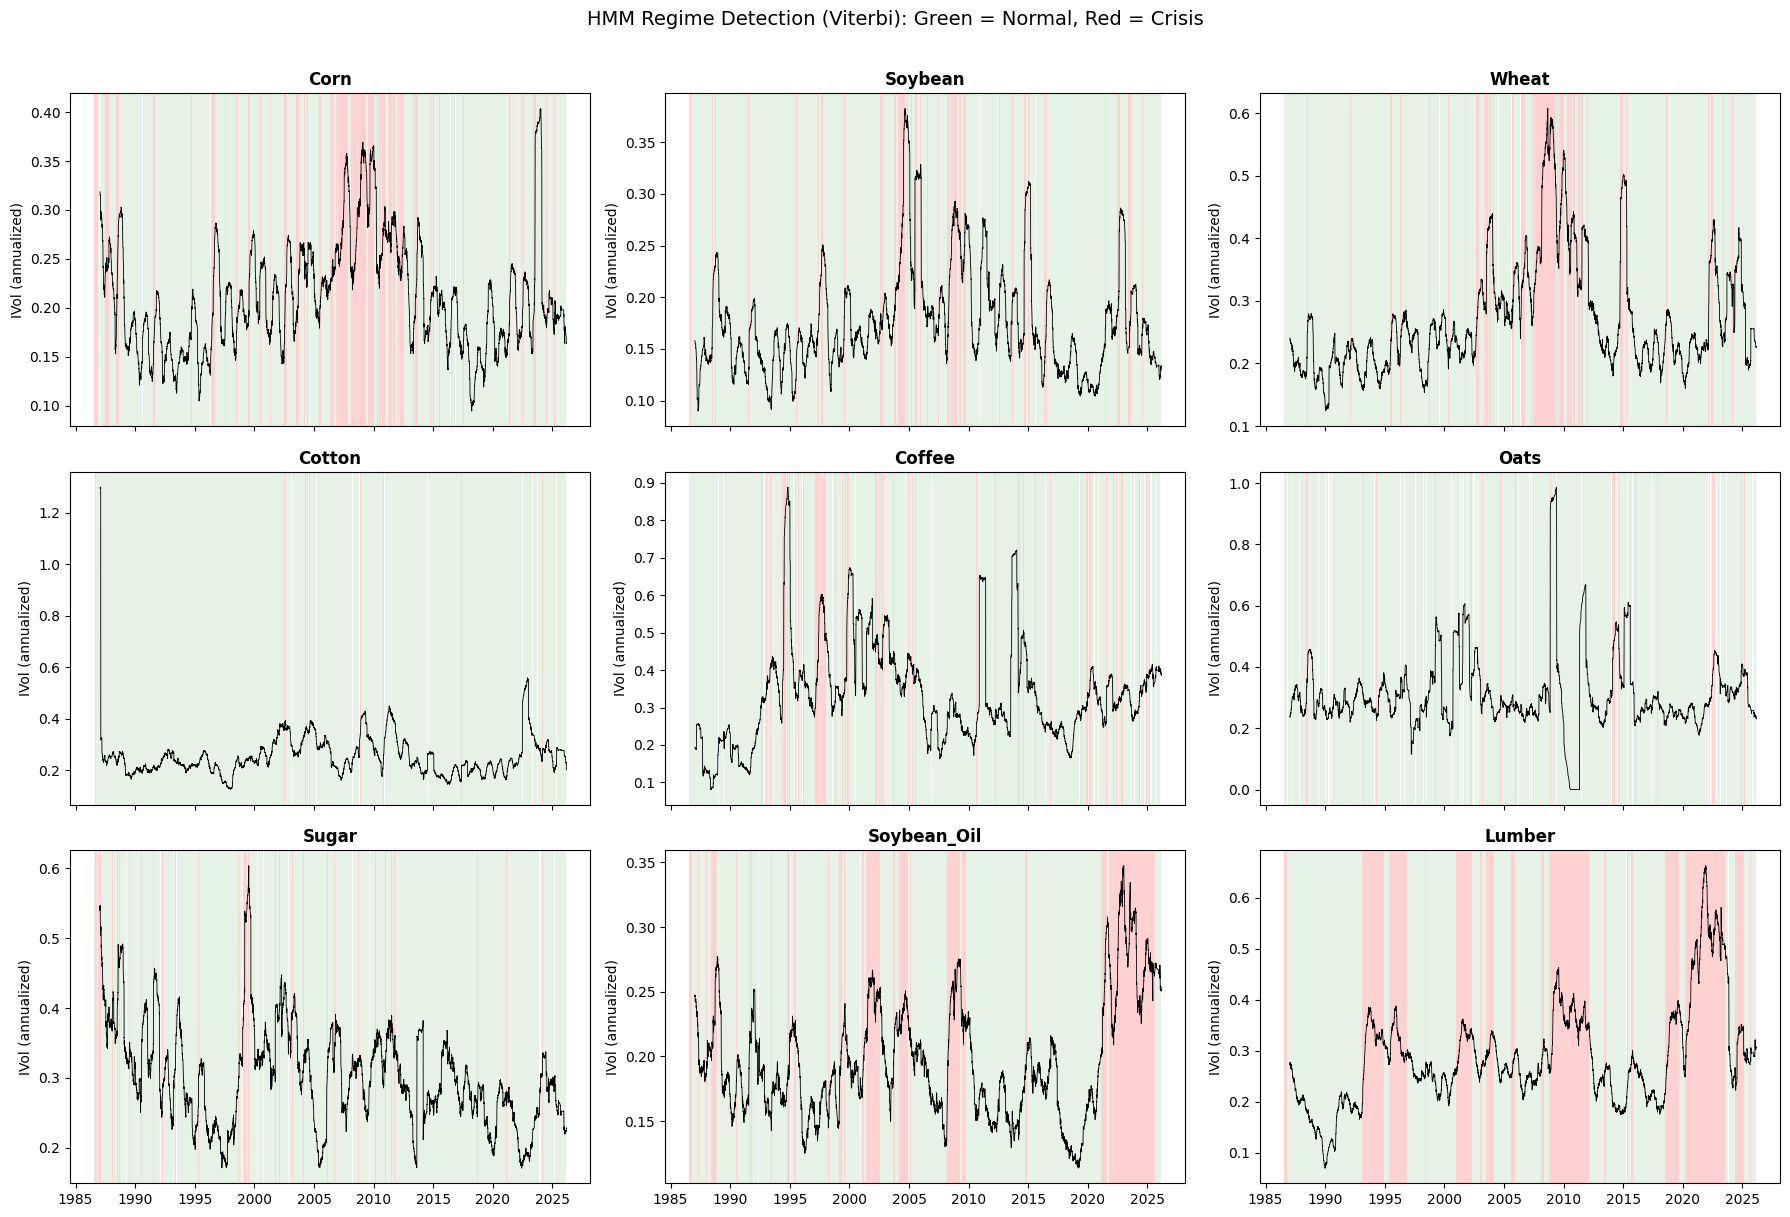

In [4]:
def regime_segments(states, dates, target_state):
    """Yield (start_date, end_date) for each contiguous run where states == target_state."""
    in_run = False
    start = None
    for i, s in enumerate(states):
        if s == target_state and not in_run:
            start = dates[i]
            in_run = True
        elif s != target_state and in_run:
            yield start, dates[i - 1]
            in_run = False
    if in_run:
        yield start, dates[-1]

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)

for idx, target in enumerate(COMMODITIES):
    ax = axes[idx // 3, idx % 3]
    r = hmm_results[target]
    dates = pd.to_datetime(r['dates'])
    viterbi = r['viterbi']
    cs = r['crisis_state']

    mask = residuals[target].notna()
    ivol_annual = volatility.loc[mask, f'{target}_IVol'].values * np.sqrt(252)

    ax.plot(dates, ivol_annual, color='black', linewidth=0.6, label='IVol (annualized)')

    for start, end in regime_segments(viterbi, dates, cs):
        ax.axvspan(start, end, alpha=0.18, color='red', linewidth=0)
    for start, end in regime_segments(viterbi, dates, 1 - cs):
        ax.axvspan(start, end, alpha=0.10, color='green', linewidth=0)

    ax.set_title(target, fontsize=12, fontweight='bold')
    ax.set_ylabel('IVol (annualized)')

fig.suptitle('HMM Regime Detection (Viterbi): Green = Normal, Red = Crisis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('data/processed/hmm_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Extract Crisis Periods for Event Study

Filter for contiguous runs where the posterior crisis probability stays above 90%. A minimum duration of 5 trading days is applied to drop single-day flickers that cannot be meaningfully tied to real-world events. Output columns:

- `Start`, `End`: first and last day of the crisis window,
- `Duration_Days`: number of trading days,
- `Peak_Prob`: maximum posterior crisis probability in the window,
- `Event`: to be filled manually from news archives (drought, freeze, policy shock, etc.).

In [5]:
MIN_DURATION = 5
PROB_THRESHOLD = 0.9

all_crisis_periods = {}

for target in COMMODITIES:
    r = hmm_results[target]
    dates = pd.to_datetime(r['dates'])
    prob = r['crisis_prob']
    is_crisis = prob > PROB_THRESHOLD

    periods = []
    in_run = False
    for i, hit in enumerate(is_crisis):
        if hit and not in_run:
            start_i = i
            in_run = True
        elif not hit and in_run:
            end_i = i - 1
            periods.append((start_i, end_i))
            in_run = False
    if in_run:
        periods.append((start_i, len(is_crisis) - 1))

    rows = []
    for si, ei in periods:
        duration = ei - si + 1
        if duration < MIN_DURATION:
            continue
        rows.append({
            'Start': dates[si].date(),
            'End': dates[ei].date(),
            'Duration_Days': int(duration),
            'Peak_Prob': round(float(prob[si:ei + 1].max()), 4),
            'Event': ''
        })

    all_crisis_periods[target] = pd.DataFrame(rows)
    pct = 100 * is_crisis.mean()
    print(f'{target:<12s} | {len(rows):3d} periods (>= {MIN_DURATION} days)  |  {pct:5.1f}% of days in crisis')

Corn         |  67 periods (>= 5 days)  |   13.1% of days in crisis
Soybean      |  39 periods (>= 5 days)  |    6.2% of days in crisis
Wheat        |  43 periods (>= 5 days)  |    9.2% of days in crisis
Cotton       |   4 periods (>= 5 days)  |    1.2% of days in crisis
Coffee       |  17 periods (>= 5 days)  |    6.3% of days in crisis
Oats         |   4 periods (>= 5 days)  |    4.7% of days in crisis
Sugar        |  15 periods (>= 5 days)  |    3.7% of days in crisis
Soybean_Oil  |  45 periods (>= 5 days)  |   12.9% of days in crisis
Lumber       |  30 periods (>= 5 days)  |   30.7% of days in crisis


In [6]:
for target in COMMODITIES:
    df = all_crisis_periods[target]
    print(f'\n=== {target}  ({len(df)} periods) ===')
    if len(df):
        display(df.head(10))


=== Corn  (67 periods) ===


,Start,End,Duration_Days,Peak_Prob,Event
0,1986-07-23,1986-08-04,9,1.0000,
1,1986-08-25,1986-09-11,12,0.9989,
2,1986-09-17,1986-11-04,33,1.0000,
3,1987-02-11,1987-02-20,6,0.9944,
4,1987-06-16,1987-07-08,16,0.9997,
5,1987-07-29,1987-08-04,5,0.9675,
6,1988-06-02,1988-08-08,46,1.0000,
7,1991-07-15,1991-07-22,6,0.9851,
8,1996-05-30,1996-06-06,6,0.9973,
9,1996-07-16,1996-07-25,8,1.0000,



=== Soybean  (39 periods) ===


,Start,End,Duration_Days,Peak_Prob,Event
0,1986-08-29,1986-09-09,6,0.9996,
1,1988-06-21,1988-08-01,28,1.0000,
2,1988-10-06,1988-10-13,6,0.9427,
3,1991-07-26,1991-08-05,7,1.0000,
4,1997-04-04,1997-04-11,6,0.9978,
5,1997-06-02,1997-06-09,6,0.9801,
6,1997-06-30,1997-07-09,6,1.0000,
7,1997-08-28,1997-09-05,5,1.0000,
8,1999-07-21,1999-08-05,12,0.9999,
9,2001-07-16,2001-07-20,5,0.9637,



=== Wheat  (43 periods) ===


...

,Start,End,Duration_Days,Peak_Prob,Event
0,1986-07-16,1986-07-25,8,1.0000,
1,1986-08-13,1986-08-19,5,1.0000,
2,1986-09-29,1986-10-06,6,0.9999,
3,1988-01-27,1988-02-02,5,1.0000,
4,1988-06-27,1988-07-07,7,1.0000,
5,1988-07-20,1988-07-28,7,1.0000,
6,1990-07-13,1990-07-19,5,1.0000,
7,1993-03-15,1993-03-19,5,1.0000,
8,1999-06-25,1999-07-12,10,1.0000,
9,2000-03-30,2000-04-05,5,0.9852,



=== Soybean_Oil  (45 periods) ===


,Start,End,Duration_Days,Peak_Prob,Event
0,1986-07-09,1986-07-21,9,1.0000,
1,1986-08-12,1986-08-26,11,0.9338,
2,1986-09-22,1986-10-31,28,1.0000,
3,1988-01-13,1988-02-02,15,0.9983,
4,1988-06-17,1988-08-03,32,1.0000,
5,1988-08-15,1988-08-24,8,0.9300,
6,1988-09-22,1988-10-26,25,1.0000,
7,1990-07-05,1990-07-23,13,0.9805,
8,1991-07-25,1991-08-14,15,1.0000,
9,1991-10-10,1991-10-16,5,1.0000,



=== Lumber  (30 periods) ===


,Start,End,Duration_Days,Peak_Prob,Event
0,1986-07-09,1986-08-25,34,1.0000,
1,1993-02-05,1994-02-17,251,1.0000,
2,1994-03-24,1994-10-21,143,1.0000,
3,1995-06-07,1995-12-08,126,1.0000,
4,1996-01-24,1996-02-01,7,0.9539,
5,1996-08-29,1996-11-14,54,0.9900,
6,1998-05-28,1998-06-16,14,0.9763,
7,2001-01-12,2001-07-17,123,1.0000,
8,2001-09-07,2002-04-15,139,1.0000,
9,2003-01-17,2003-02-11,16,0.9973,


### 3.6 Save Phase 3 Outputs

Exported artifacts for Phase 4:
- `hmm_crisis_probabilities.csv`: Date + posterior crisis probability per commodity,
- `hmm_viterbi_states.csv`: Date + binary regime (0 = Normal, 1 = Crisis) per commodity,
- `crisis_periods/{Commodity}_crisis_periods.csv`: candidate windows for the event study.

In [ ]:
prob_out = pd.DataFrame({'Date': residuals['Date']})
state_out = pd.DataFrame({'Date': residuals['Date']})

for target in COMMODITIES:
    mask = residuals[target].notna()
    r = hmm_results[target]

    prob_series = pd.Series(np.nan, index=residuals.index)
    prob_series[mask] = r['crisis_prob']
    prob_out[f'{target}_CrisisProb'] = prob_series

    state_series = pd.Series(np.nan, index=residuals.index)
    viterbi_labeled = (r['viterbi'] == r['crisis_state']).astype(int)
    state_series[mask] = viterbi_labeled
    state_out[f'{target}_State'] = state_series

prob_out.to_csv('data/processed/hmm_crisis_probabilities.csv', index=False)
state_out.to_csv('data/processed/hmm_viterbi_states.csv', index=False)
print(f'Saved hmm_crisis_probabilities.csv: {prob_out.shape}')
print(f'Saved hmm_viterbi_states.csv: {state_out.shape}')

os.makedirs('data/processed/crisis_periods', exist_ok=True)
for target in COMMODITIES:
    df = all_crisis_periods[target]
    path = f'data/processed/crisis_periods/{target}_crisis_periods.csv'
    df.to_csv(path, index=False)
    print(f'Saved {path}: {len(df)} periods')

print('\nPhase 3 complete. Next step: fill the Event column in each crisis_periods CSV with real-world news.')

Saved hmm_crisis_probabilities.csv: (9601, 10)
Saved hmm_viterbi_states.csv: (9601, 10)
Saved data/processed/crisis_periods/Corn_crisis_periods.csv: 67 periods
Saved data/processed/crisis_periods/Soybean_crisis_periods.csv: 39 periods
Saved data/processed/crisis_periods/Wheat_crisis_periods.csv: 43 periods
Saved data/processed/crisis_periods/Cotton_crisis_periods.csv: 4 periods
Saved data/processed/crisis_periods/Coffee_crisis_periods.csv: 17 periods
Saved data/processed/crisis_periods/Oats_crisis_periods.csv: 4 periods
Saved data/processed/crisis_periods/Sugar_crisis_periods.csv: 15 periods
Saved data/processed/crisis_periods/Soybean_Oil_crisis_periods.csv: 45 periods
Saved data/processed/crisis_periods/Lumber_crisis_periods.csv: 30 periods

Phase 3 complete. Next step: fill the Event column in each crisis_periods CSV with real-world news.


: 